In [1]:
import os
import re
import csv
import numpy as np

In [2]:
cwd = os.getcwd()

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Batch Data Transfer Analysis
Compare the new batch data transfer (CompactTipStates) IQ-TREE GPU results against previous backends:
- PROTOTYPE_GPU_V100 (our custom implementation)
- IQ-TREE_GPU_V100 (IQ-TREE OpenACC)
- IQ-TREE_CPU_1_CORE
- IQ-TREE_CPU_10_CORES
- IQ-TREE_CPU_48_CORES
- **IQ-TREE_BatchTransfer_GPU_V100** (NEW)

# Prepare CSV

In [4]:
AA_folder = "100taxa_diff_trees_1M_sites_AA"
DNA_folder = "100taxa_diff_trees_1M_sites"

In [5]:
previous_results_path = "/Users/u7826985/Projects/Nvidia/results/2026_03_04_wholetest"
new_results_path = "/Users/u7826985/Projects/Nvidia/results/2026_03_06_batch_data_transfer"

output_csv = f"{cwd}/results_aa.csv"
output_csv_dna = f"{cwd}/results_dna.csv"

In [6]:
# Regex to capture the RESULT line (for prototype GPU .txt files)
pattern = re.compile(
    r"\[RESULT\]\s*backend=(\w+)\s+taxa=(\d+)\s+sites=(\d+)\s+patterns=(\d+)\s+time=([\d\.e\+\-]+)s\s+likelihood=([\-.\deE]+)"
)

# Regex patterns for IQ-TREE log files
alignment_pattern = re.compile(r"Alignment has (\d+) sequences with (\d+) columns, (\d+) distinct patterns")
likelihood_pattern = re.compile(r"Initial log-likelihood:\s+([-0-9.]+)")
params_opt_pattern = re.compile(r"Parameters optimization took \d+ rounds? \(([0-9.]+) sec\)")
wallclock_pattern = re.compile(r"Total wall-clock time used:\s+([0-9.]+)\s+sec")

In [7]:
def read_files_in_directory(directory, unique_name=""):
    """Read prototype GPU results from .txt files"""
    for i in range(1, 11):
        tree_folder = f"{directory}/tree_{i}"
        files = os.listdir(tree_folder)
        for file in files:
            if file.endswith('.txt'):
                with open(f'{tree_folder}/{file}', 'r') as f:
                    tree_file_name = file.split("_")[4] + "_" + file.split("_")[5]
                    run_number = file.split("_")[3]
                    
                    h200 = False
                    a100 = False
                    if "h200" in file.split("_")[-1]:
                        h200 = True
                    elif "a100" in file.split("_")[-1]:
                        a100 = True
                        continue
                    
                    for line in f:
                        match = pattern.search(line)
                        if match:
                            backend, taxa, sites, patterns, time, likelihood = match.groups()
                            backend = "PROTOTYPE_GPU"
                            if h200:
                                backend += "_H200"
                            elif a100:
                                backend += "_A100"
                            else:
                                backend += "_V100"
                            data.append([backend, taxa, sites, patterns, likelihood, time, tree_file_name, run_number])
    print(f"Extracted {len(data)} results")

In [8]:
def read_iqtree_results(directory, backend_prefix="IQ-TREE"):
    """Read IQ-TREE results from .log files"""
    for i in range(1, 11):
        tree_folder = f"{directory}/tree_{i}"
        files = os.listdir(tree_folder)
        for file in files:
            if file.endswith('.log'):
                with open(f'{tree_folder}/{file}', 'r') as f:
                    content = f.read()
                    parts = file.split("_")
                    extype = parts[3]           # OPENACC or VANILA
                    run_number = parts[4]        # run1, run2, ...
                    tree_file = parts[5] + "_" + parts[6]  # tree_1, tree_2, ...

                    aln_match = alignment_pattern.search(content)
                    ll_match = likelihood_pattern.search(content)
                    opt_match = params_opt_pattern.search(content)

                    if aln_match and ll_match and opt_match:
                        taxa = int(aln_match.group(1))
                        sites = int(aln_match.group(2))
                        patterns = int(aln_match.group(3))
                        likelihood = float(ll_match.group(1))
                        time = float(opt_match.group(1))

                        if extype != "VANILA":
                            backend = f"{backend_prefix}_GPU_V100"
                        else:
                            if "10CPU" in file:
                                backend = f"{backend_prefix}_CPU_10_CORES"
                            elif "48CPU" in file:
                                backend = f"{backend_prefix}_CPU_48_CORES"
                            else:
                                backend = f"{backend_prefix}_CPU_1_CORE"

                        data.append([backend, taxa, sites, patterns, likelihood, time, tree_file, run_number])
    print(f"Extracted {len(data)} results")

In [9]:
def write_to_csv(data, output_csv):
    with open(output_csv, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(["backend", "taxa", "sites", "patterns", "likelihood", "time", "treefile", "run_number"])
        writer.writerows(data)

In [10]:
def plot_average_time_per_backend(df, logy=False, path=""):
    groups = df.groupby(['treefile', 'backend'])
    mean_times = groups['time'].mean().unstack()
    mean_times.plot(kind='bar', figsize=(10, 5))
    if logy:
        plt.yscale('log')
    plt.xlabel('Tree File')
    plt.ylabel('Average Time (s)')
    plt.title('Average Time per Backend for Each Tree File')
    plt.tight_layout()
    if path:
        plt.savefig(path)
    plt.show()


def plot_min_time_per_backend(df, logy=False, path=""):
    groups = df.groupby(['treefile', 'backend'])
    min_times = groups['time'].min().unstack()
    min_times.plot(kind='bar', figsize=(10, 5))
    if logy:
        plt.yscale('log')
    plt.xlabel('Tree File')
    plt.ylabel('Min Time (s)')
    plt.title('Minimum Time per Backend for Each Tree File')
    plt.tight_layout()
    if path:
        plt.savefig(path)
    plt.show()


def plot_max_time_per_backend(df, logy=False, path=""):
    groups = df.groupby(['treefile', 'backend'])
    max_times = groups['time'].max().unstack()
    max_times.plot(kind='bar', figsize=(10, 5))
    if logy:
        plt.yscale('log')
    plt.xlabel('Tree File')
    plt.ylabel('Max Time (s)')
    plt.title('Max Time per Backend for Each Tree File')
    plt.tight_layout()
    if path:
        plt.savefig(path)
    plt.show()

In [11]:
def plot_runtime_boxplot_auto(
    df,
    tree_col=None,
    backend_col=None,
    time_col=None,
    backend_cols=None,
    figsize=(14, 6),
    show_outliers=True,
    title="Runtime Distribution per Tree per Backend",
    rotate_xticks=45,
    logy=False,
    path=""
):
    df = df.copy()
    cols = list(df.columns)

    if tree_col is None:
        for c in cols:
            lc = c.lower()
            if lc in ("tree", "tree_file", "treefile", "tree_id", "treeid", "file"):
                tree_col = c
                break
        if tree_col is None:
            non_numeric = [c for c in cols if not pd.api.types.is_numeric_dtype(df[c])]
            tree_col = non_numeric[0] if non_numeric else cols[0]

    if backend_cols is not None:
        wide_backend_cols = backend_cols
    else:
        wide_backend_cols = None

    has_long = (
        (backend_col is not None and backend_col in df.columns) or
        any(c.lower() in ("backend", "impl", "implementation") for c in cols)
    ) and (
        (time_col is not None and time_col in df.columns) or
        any(c.lower() in ("time", "runtime", "elapsed", "elapsed_time", "seconds", "sec", "min_time") for c in cols)
    )

    if has_long:
        if backend_col is None:
            backend_col = next(c for c in cols if c.lower() in ("backend", "impl", "implementation"))
        if time_col is None:
            time_col = next(c for c in cols if c.lower() in ("time", "runtime", "elapsed", "elapsed_time", "seconds", "sec", "min_time"))

        plot_df = df[[tree_col, backend_col, time_col]].copy()
        plot_df[time_col] = pd.to_numeric(plot_df[time_col], errors="coerce")
        plot_df = plot_df.dropna(subset=[time_col])
        x, y, h = tree_col, time_col, backend_col
    else:
        if wide_backend_cols is None:
            wide_backend_cols = [c for c in cols if c != tree_col]
            keep = []
            for c in wide_backend_cols:
                s = pd.to_numeric(df[c], errors="coerce")
                if s.notna().any():
                    keep.append(c)
            wide_backend_cols = keep

        plot_df = df[[tree_col] + wide_backend_cols].copy()
        plot_df = plot_df.melt(id_vars=[tree_col], value_vars=wide_backend_cols,
                               var_name="backend", value_name="time")
        plot_df["time"] = pd.to_numeric(plot_df["time"], errors="coerce")
        plot_df = plot_df.dropna(subset=["time"])
        x, y, h = tree_col, "time", "backend"

    plt.figure(figsize=figsize)
    sns.boxplot(data=plot_df, x=x, y=y, hue=h, showfliers=show_outliers)
    plt.title(title)
    plt.xlabel("Tree File")
    plt.ylabel("Time (s)")
    if logy:
        plt.yscale('log')
    plt.xticks(rotation=rotate_xticks)
    plt.legend(title="Backend", bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=len(plot_df[h].unique()))
    plt.tight_layout()
    if path:
        plt.savefig(path, bbox_inches='tight')
    plt.show()
    print("Using columns ->", {"tree": x, "backend": h, "time": y})
    print("Rows plotted:", len(plot_df))

In [12]:
def plot_bar_with_box(df, tree_col="treefile", time_col="time", backend_col="backend", figsize=(14,6), path=""):
    plt.figure(figsize=figsize)
    sns.boxplot(data=df, x=tree_col, y=time_col, hue=backend_col, showfliers=False, linewidth=1)
    sns.barplot(data=df, x=tree_col, y=time_col, hue=backend_col, estimator="mean", errorbar=None, alpha=0.4, dodge=True)
    plt.title("Runtime Distribution + Mean per Tree per Backend")
    plt.xticks(rotation=45)
    plt.ylabel("Time (s)")
    plt.xlabel("Tree File")
    handles, labels = plt.gca().get_legend_handles_labels()
    n = len(df[backend_col].unique())
    plt.legend(handles[:n], labels[:n], title="Backend", bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=n)
    plt.tight_layout()
    if path:
        plt.savefig(path, bbox_inches='tight')
    plt.show()

# AA Analysis - All Backends + Batch Data Transfer

In [13]:
data = []

# Read previous results: prototype GPU + IQ-TREE backends
read_files_in_directory(f"{previous_results_path}/{AA_folder}")
read_iqtree_results(f"{previous_results_path}/{AA_folder}", backend_prefix="IQ-TREE")

# Read new batch data transfer results
read_iqtree_results(f"{new_results_path}/{AA_folder}", backend_prefix="IQ-TREE_BatchTransfer")

write_to_csv(data, output_csv)
print(f"Total rows: {len(data)}")

Extracted 100 results
Extracted 500 results
Extracted 600 results
Total rows: 600


In [14]:
df = pd.read_csv(output_csv)
df

,backend,taxa,sites,patterns,likelihood,time,treefile,run_number
0,PROTOTYPE_GPU_V100,100,1000000,1000000,-1.104132e+08,1.302389,tree_1,run9
1,PROTOTYPE_GPU_V100,100,1000000,1000000,-1.104132e+08,1.327172,tree_1,run2
2,PROTOTYPE_GPU_V100,100,1000000,1000000,-1.104132e+08,1.275145,tree_1,run10
3,PROTOTYPE_GPU_V100,100,1000000,1000000,-1.104132e+08,1.288577,tree_1,run4
4,PROTOTYPE_GPU_V100,100,1000000,1000000,-1.104132e+08,1.311187,tree_1,run8
...,...,...,...,...,...,...,...,...
595,IQ-TREE_BatchTransfer_GPU_V100,100,1000000,1000000,-1.065590e+08,6.718000,tree_10,run3
596,IQ-TREE_BatchTransfer_GPU_V100,100,1000000,1000000,-1.065590e+08,6.848000,tree_10,run4
597,IQ-TREE_BatchTransfer_GPU_V100,100,1000000,1000000,-1.065590e+08,6.901000,tree_10,run2
598,IQ-TREE_BatchTransfer_GPU_V100,100,1000000,1000000,-1.065590e+08,6.987000,tree_10,run10


In [15]:
df.groupby('backend')['time'].describe()

,count,mean,std,min,25%,50%,75%,max
backend,,,,,,,,
IQ-TREE_BatchTransfer_GPU_V100,100.0,6.851040,0.077751,6.679000,6.800000,6.87000,6.903250,7.017000
IQ-TREE_CPU_10_CORES,100.0,1.694250,0.190401,1.524000,1.594250,1.64800,1.701250,2.841000
IQ-TREE_CPU_1_CORE,100.0,13.177120,0.277224,12.668000,13.024500,13.14700,13.279500,14.411000
IQ-TREE_CPU_48_CORES,100.0,0.923250,0.032937,0.875000,0.904000,0.91500,0.935250,1.051000
IQ-TREE_GPU_V100,100.0,6.830970,0.094041,6.602000,6.772250,6.84500,6.894000,7.018000
PROTOTYPE_GPU_V100,100.0,1.289795,0.032354,1.228376,1.270364,1.28698,1.306522,1.439183


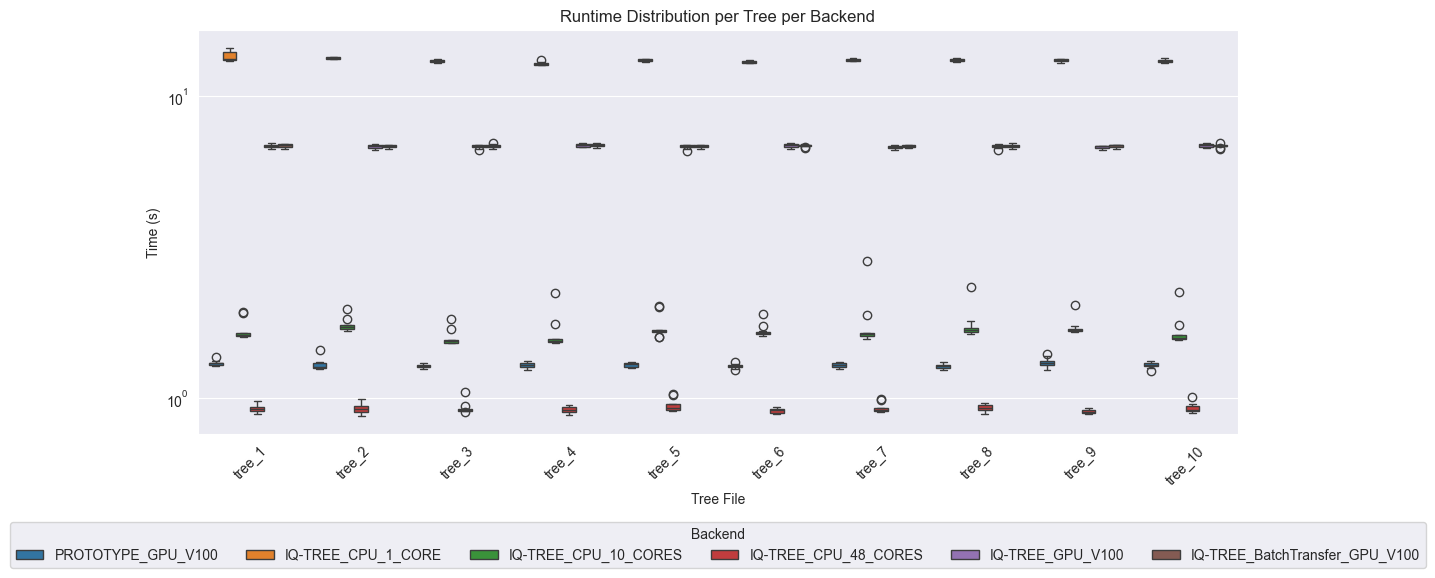

Using columns -> {'tree': 'treefile', 'backend': 'backend', 'time': 'time'}
Rows plotted: 600


In [16]:
plot_runtime_boxplot_auto(df, logy=True, path=f"{cwd}/aa_boxonly.png")

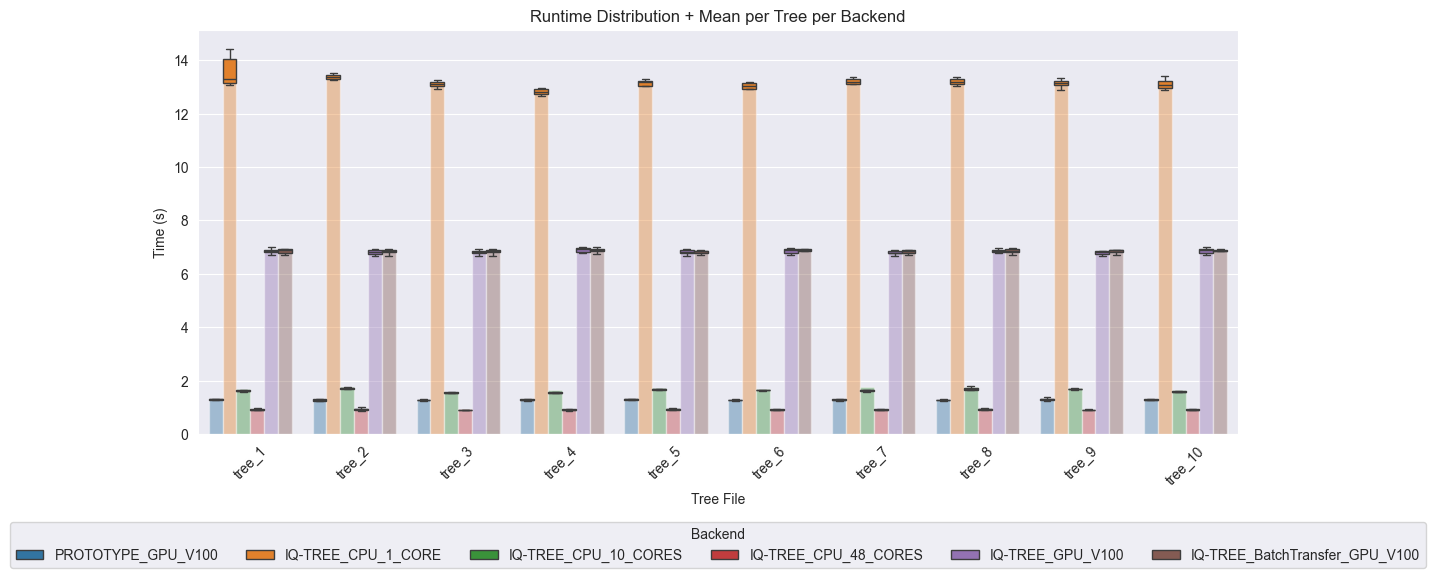

In [17]:
plot_bar_with_box(df, path=f"{cwd}/aa_boxplot.png")

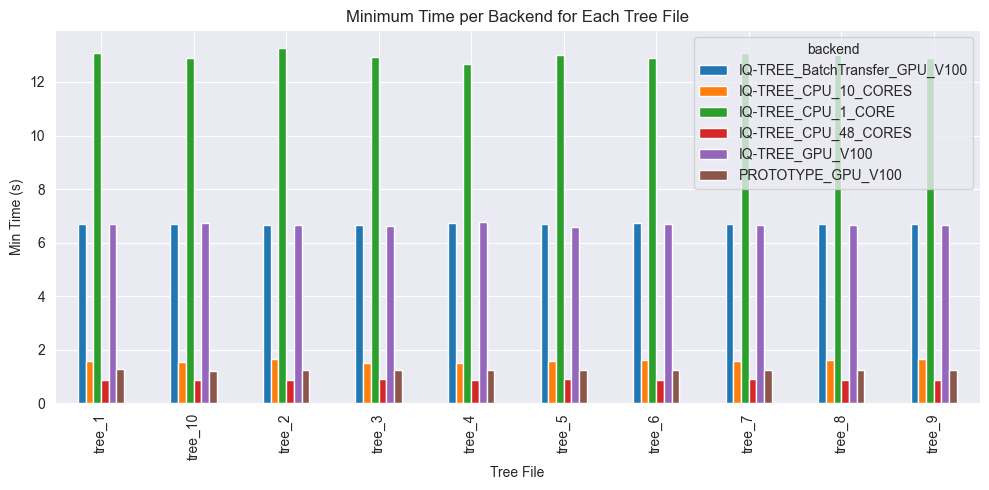

In [18]:
plot_min_time_per_backend(df, logy=False, path=f"{cwd}/min_time_per_backend_AA.png")

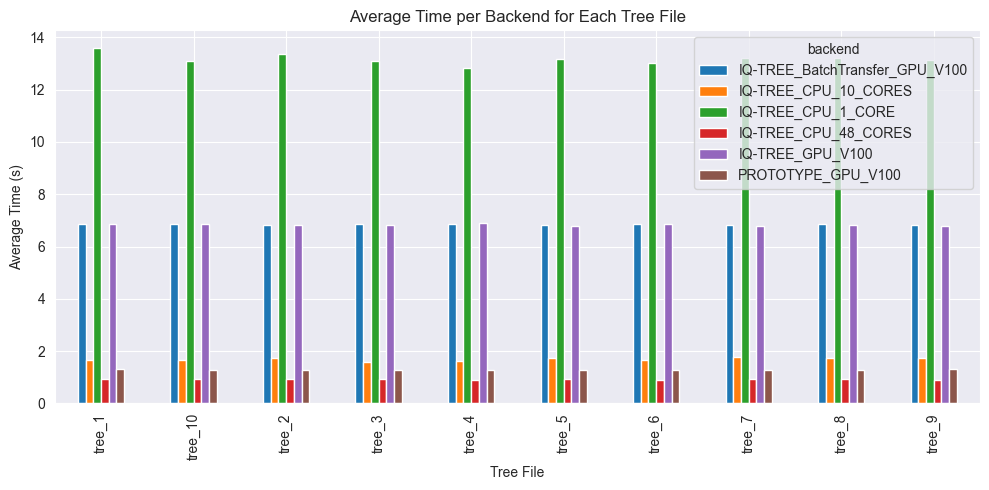

In [19]:
plot_average_time_per_backend(df, logy=False, path=f"{cwd}/average_time_per_backend_AA.png")

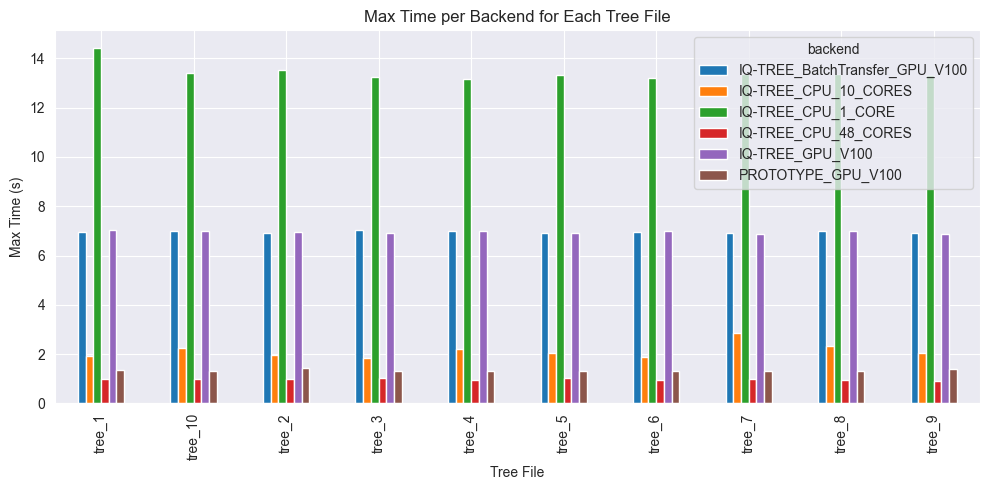

In [20]:
plot_max_time_per_backend(df, logy=False, path=f"{cwd}/max_time_per_backend_AA.png")

## Batch Data Transfer vs Previous IQ-TREE GPU (AA)
Direct comparison between the old and new IQ-TREE GPU backends

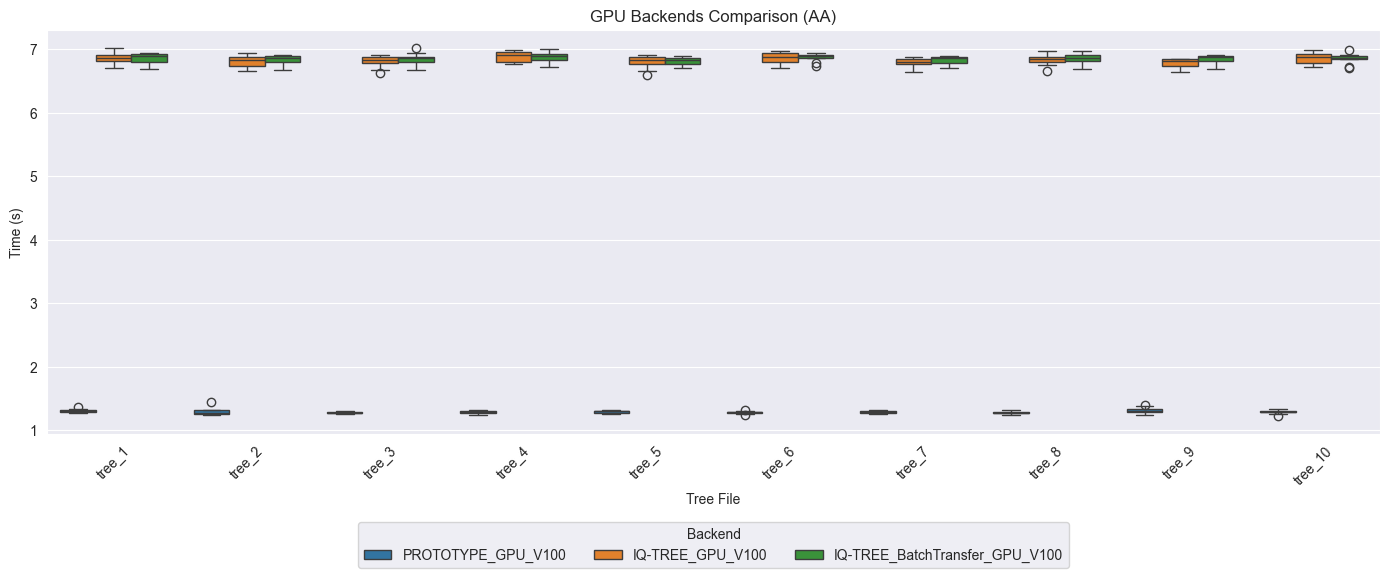

Using columns -> {'tree': 'treefile', 'backend': 'backend', 'time': 'time'}
Rows plotted: 300


In [21]:
# Filter to only GPU backends for direct comparison
gpu_backends = ['IQ-TREE_GPU_V100', 'IQ-TREE_BatchTransfer_GPU_V100', 'PROTOTYPE_GPU_V100']
df_gpu = df[df['backend'].isin(gpu_backends)].copy()

plot_runtime_boxplot_auto(df_gpu, logy=False, title="GPU Backends Comparison (AA)", path=f"{cwd}/gpu_comparison_AA.png")

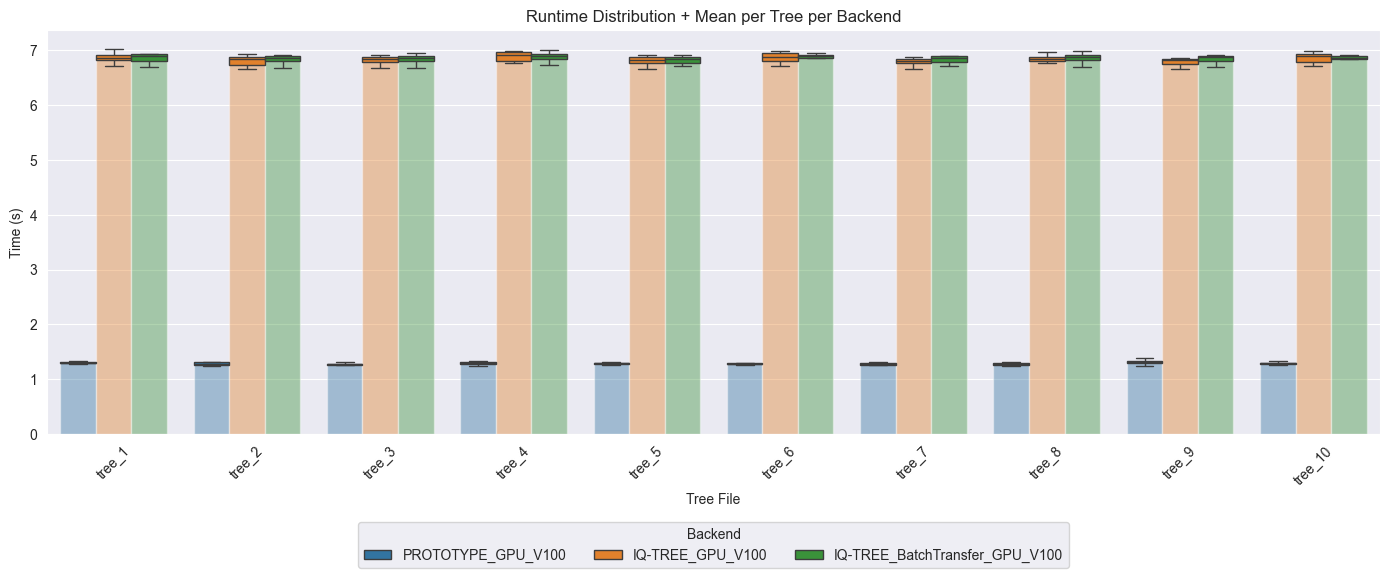

In [22]:
plot_bar_with_box(df_gpu, path=f"{cwd}/gpu_comparison_barbox_AA.png")

In [23]:
# Speedup table: BatchTransfer vs previous IQ-TREE GPU
mean_by_backend = df.groupby(['treefile', 'backend'])['time'].mean().unstack()

if 'IQ-TREE_GPU_V100' in mean_by_backend.columns and 'IQ-TREE_BatchTransfer_GPU_V100' in mean_by_backend.columns:
    speedup = mean_by_backend['IQ-TREE_GPU_V100'] / mean_by_backend['IQ-TREE_BatchTransfer_GPU_V100']
    speedup_df = pd.DataFrame({
        'IQ-TREE_GPU_V100 (mean s)': mean_by_backend['IQ-TREE_GPU_V100'],
        'IQ-TREE_BatchTransfer_GPU_V100 (mean s)': mean_by_backend['IQ-TREE_BatchTransfer_GPU_V100'],
        'Speedup (old/new)': speedup
    })
    display(speedup_df)
    print(f"\nOverall average speedup: {speedup.mean():.3f}x")
else:
    print("Missing one of the backends for speedup calculation")
    print("Available backends:", mean_by_backend.columns.tolist())

,IQ-TREE_GPU_V100 (mean s),IQ-TREE_BatchTransfer_GPU_V100 (mean s),Speedup (old/new)
treefile,,,
tree_1,6.8609,6.8581,1.000408
tree_10,6.8657,6.8545,1.001634
tree_2,6.8108,6.8417,0.995484
tree_3,6.8128,6.8491,0.994700
tree_4,6.8922,6.8746,1.002560
tree_5,6.8055,6.8224,0.997523
tree_6,6.8612,6.8777,0.997601
tree_7,6.7832,6.8328,0.992741
tree_8,6.8358,6.8560,0.997054



Overall average speedup: 0.997x


# DNA Analysis - All Backends + Batch Data Transfer

In [24]:
data = []

# Read previous results: prototype GPU + IQ-TREE backends
read_files_in_directory(f"{previous_results_path}/{DNA_folder}")
read_iqtree_results(f"{previous_results_path}/{DNA_folder}", backend_prefix="IQ-TREE")

# Read new batch data transfer DNA results
read_iqtree_results(f"{new_results_path}/{DNA_folder}", backend_prefix="IQ-TREE_BatchTransfer")

write_to_csv(data, output_csv_dna)
df_dna = pd.read_csv(output_csv_dna)
print(f"Total rows: {len(df_dna)}")
df_dna

Extracted 100 results
Extracted 500 results
Extracted 600 results
Total rows: 600


,backend,taxa,sites,patterns,likelihood,time,treefile,run_number
0,PROTOTYPE_GPU_V100,100,1000000,1000000,-7.005168e+07,1.233555,tree_1,run9
1,PROTOTYPE_GPU_V100,100,1000000,1000000,-7.005168e+07,1.206464,tree_1,run6
2,PROTOTYPE_GPU_V100,100,1000000,1000000,-7.005168e+07,1.210843,tree_1,run5
3,PROTOTYPE_GPU_V100,100,1000000,1000000,-7.005168e+07,1.232884,tree_1,run3
4,PROTOTYPE_GPU_V100,100,1000000,1000000,-7.005168e+07,1.373047,tree_1,run8
...,...,...,...,...,...,...,...,...
595,IQ-TREE_BatchTransfer_GPU_V100,100,1000000,1000000,-6.804077e+07,3.119000,tree_10,run9
596,IQ-TREE_BatchTransfer_GPU_V100,100,1000000,1000000,-6.804077e+07,3.073000,tree_10,run7
597,IQ-TREE_BatchTransfer_GPU_V100,100,1000000,1000000,-6.804077e+07,3.101000,tree_10,run10
598,IQ-TREE_BatchTransfer_GPU_V100,100,1000000,1000000,-6.804077e+07,3.047000,tree_10,run6


In [25]:
df_dna.groupby('backend')['time'].describe()

,count,mean,std,min,25%,50%,75%,max
backend,,,,,,,,
IQ-TREE_BatchTransfer_GPU_V100,100.0,3.102990,0.034457,3.038000,3.075750,3.104000,3.125250,3.213000
IQ-TREE_CPU_10_CORES,100.0,0.338700,0.081631,0.243000,0.280000,0.335500,0.370000,0.690000
IQ-TREE_CPU_1_CORE,100.0,1.922740,0.075055,1.850000,1.882750,1.900500,1.926750,2.361000
IQ-TREE_CPU_48_CORES,100.0,0.209830,0.006865,0.197000,0.205000,0.209000,0.213250,0.227000
IQ-TREE_GPU_V100,100.0,3.054010,0.058075,2.919000,3.005000,3.057500,3.092250,3.188000
PROTOTYPE_GPU_V100,100.0,1.196307,0.036660,1.137106,1.175628,1.194205,1.211239,1.373047


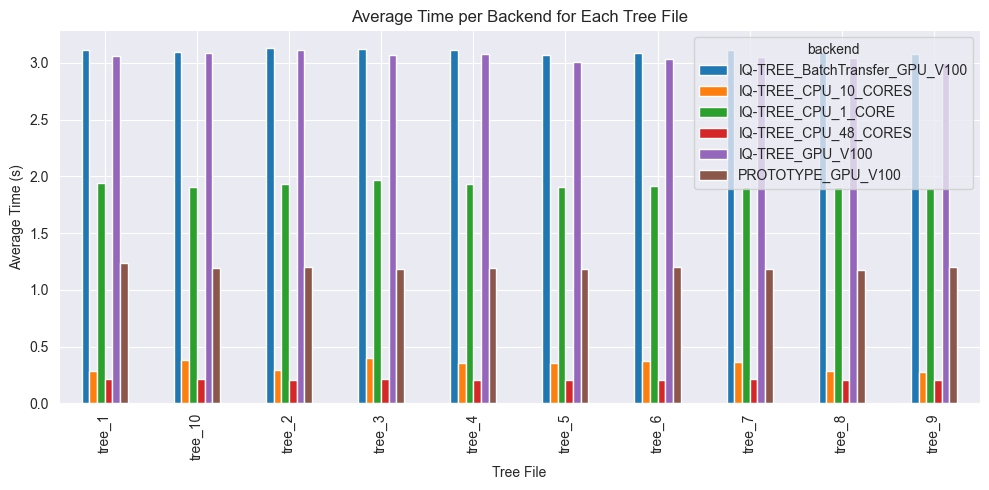

In [26]:
plot_average_time_per_backend(df_dna, logy=False, path=f"{cwd}/average_time_per_backend_DNA.png")

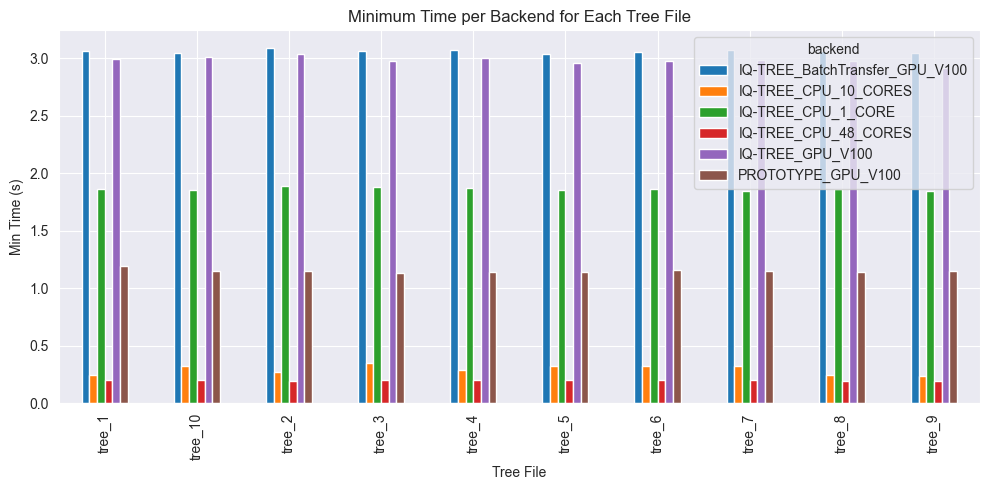

In [27]:
plot_min_time_per_backend(df_dna, logy=False, path=f"{cwd}/min_time_per_backend_DNA.png")

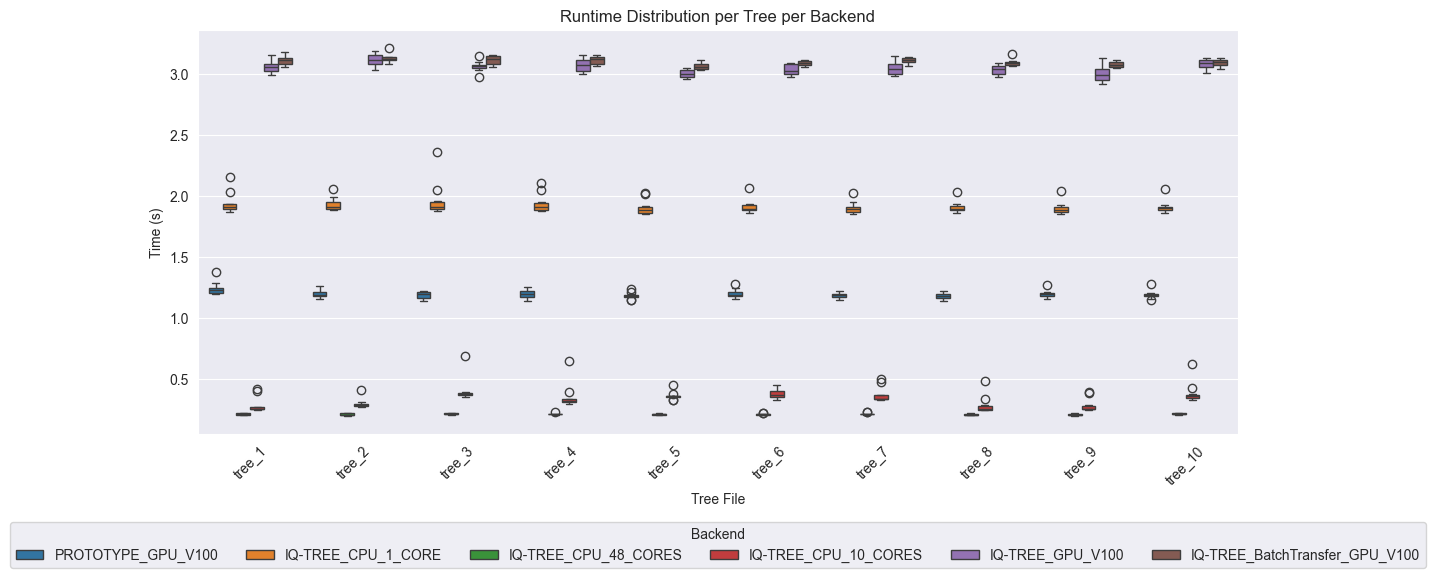

Using columns -> {'tree': 'treefile', 'backend': 'backend', 'time': 'time'}
Rows plotted: 600


In [28]:
plot_runtime_boxplot_auto(df_dna, path=f"{cwd}/DNA_boxonly.png")

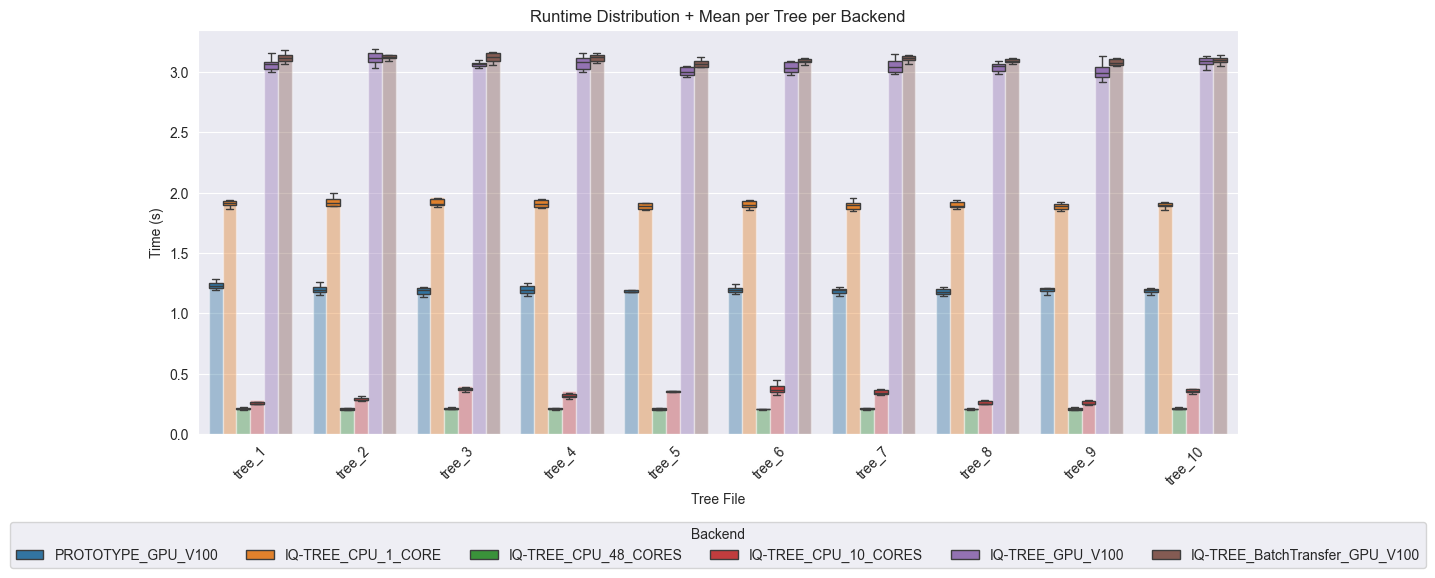

In [29]:
plot_bar_with_box(df_dna, path=f"{cwd}/DNA_boxplot.png")

## Batch Data Transfer vs Previous IQ-TREE GPU (DNA)
Direct comparison between the old and new IQ-TREE GPU backends for DNA

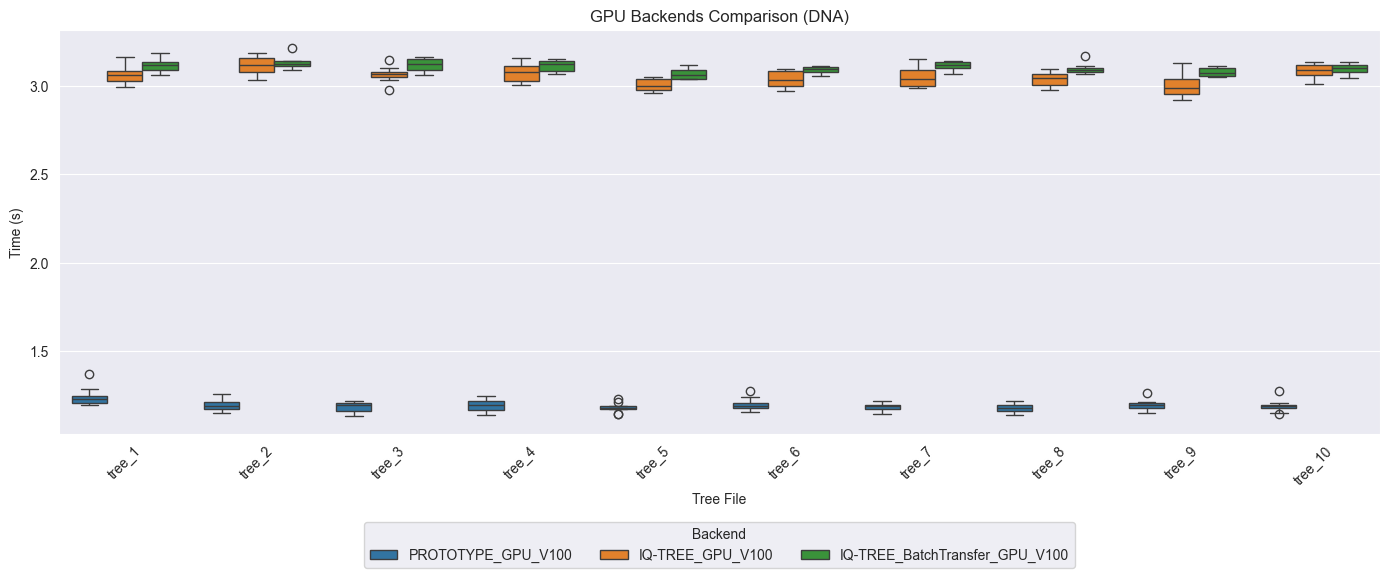

Using columns -> {'tree': 'treefile', 'backend': 'backend', 'time': 'time'}
Rows plotted: 300


In [30]:
# Filter to only GPU backends for direct comparison (DNA)
gpu_backends = ['IQ-TREE_GPU_V100', 'IQ-TREE_BatchTransfer_GPU_V100', 'PROTOTYPE_GPU_V100']
df_dna_gpu = df_dna[df_dna['backend'].isin(gpu_backends)].copy()

plot_runtime_boxplot_auto(df_dna_gpu, logy=False, title="GPU Backends Comparison (DNA)", path=f"{cwd}/gpu_comparison_DNA.png")

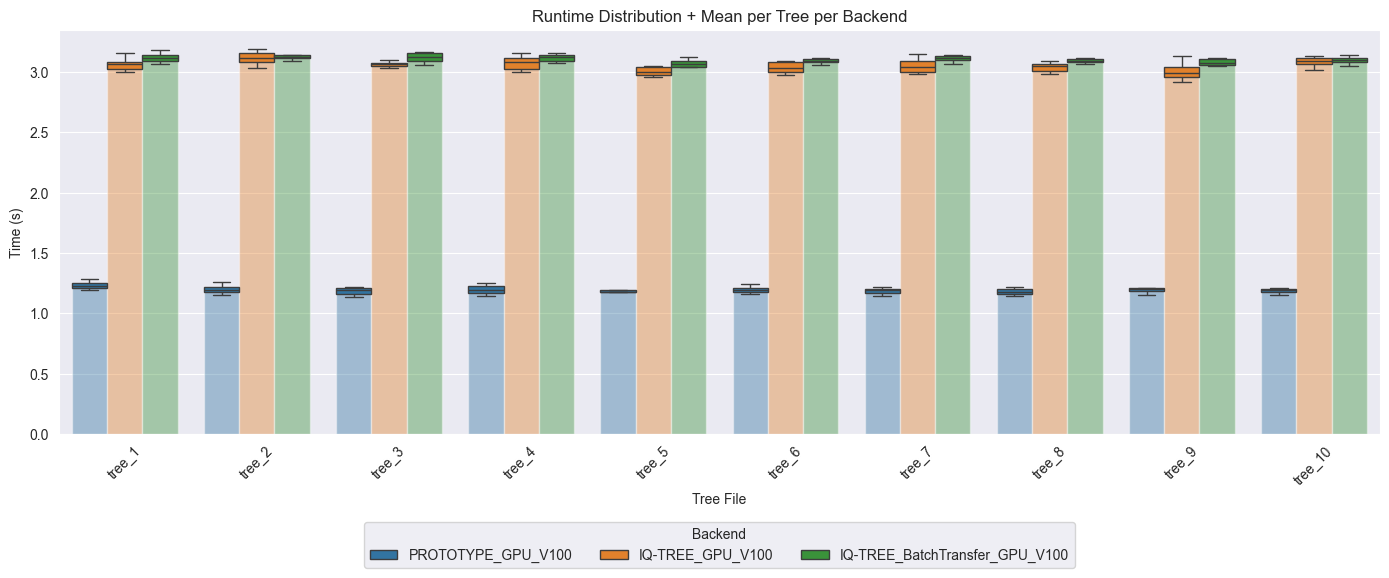

In [31]:
plot_bar_with_box(df_dna_gpu, path=f"{cwd}/gpu_comparison_barbox_DNA.png")

In [32]:
# Speedup table: BatchTransfer vs previous IQ-TREE GPU (DNA)
mean_by_backend_dna = df_dna.groupby(['treefile', 'backend'])['time'].mean().unstack()

if 'IQ-TREE_GPU_V100' in mean_by_backend_dna.columns and 'IQ-TREE_BatchTransfer_GPU_V100' in mean_by_backend_dna.columns:
    speedup_dna = mean_by_backend_dna['IQ-TREE_GPU_V100'] / mean_by_backend_dna['IQ-TREE_BatchTransfer_GPU_V100']
    speedup_dna_df = pd.DataFrame({
        'IQ-TREE_GPU_V100 (mean s)': mean_by_backend_dna['IQ-TREE_GPU_V100'],
        'IQ-TREE_BatchTransfer_GPU_V100 (mean s)': mean_by_backend_dna['IQ-TREE_BatchTransfer_GPU_V100'],
        'Speedup (old/new)': speedup_dna
    })
    display(speedup_dna_df)
    print(f"\nOverall average speedup (DNA): {speedup_dna.mean():.3f}x")
else:
    print("Missing one of the backends for speedup calculation")
    print("Available backends:", mean_by_backend_dna.columns.tolist())

,IQ-TREE_GPU_V100 (mean s),IQ-TREE_BatchTransfer_GPU_V100 (mean s),Speedup (old/new)
treefile,,,
tree_1,3.0618,3.1153,0.982827
tree_10,3.0880,3.0962,0.997352
tree_2,3.1153,3.1312,0.994922
tree_3,3.0662,3.1199,0.982788
tree_4,3.0765,3.1151,0.987609
tree_5,3.0060,3.0694,0.979344
tree_6,3.0364,3.0912,0.982272
tree_7,3.0494,3.1148,0.979003
tree_8,3.0400,3.0969,0.981627



Overall average speedup (DNA): 0.984x
